# Lab 2: Vector Analysis -- Infrastructure Exposure Assessment
## ENCN205 -- Applied Data Analysis for Civil and Natural Systems
### University of Canterbury | Te Whare Wananga o Waitaha

**Duration:** 2-3 hours  
**Week:** 2  
**Prerequisites:** Lab 1 completed (data loading, CRS, basic plotting)

---

### Learning Objectives
By the end of this lab you will be able to:
1. Load multi-layer GeoPackage files and inspect their contents
2. Filter GeoDataFrames using attribute queries
3. Join attribute tables to spatial data using `.merge()`
4. Perform spatial joins using `gpd.sjoin()`
5. Create buffer zones around infrastructure features
6. Clip spatial data to a study area boundary
7. Compute spatial aggregations using `.dissolve()` and `.groupby()`
8. Build interactive web maps with `.explore()`

### Engineering Scenario
> **You are a graduate engineer** at a consulting firm assessing coastal infrastructure
> exposure for the Christchurch City Council. Your task is to determine which buildings,
> roads, and communities are at risk from sea-level rise in the 0-5 m elevation zone.
> You will combine real building footprints, road centrelines, suburb boundaries, and
> hazard data to produce an exposure report.
>
> The data comes from real LINZ (Land Information New Zealand) datasets for eastern
> Christchurch -- the area most affected by the 2010-2011 Canterbury earthquakes and
> ongoing coastal hazard management.

## 1. Setup and Data Loading

Our data is stored in a **GeoPackage** (`.gpkg`) -- a modern, open-standard spatial
database format that can hold multiple layers in a single file. It's the recommended
replacement for Shapefiles.

The file `christchurch.gpkg` contains five layers:
| Layer | Geometry | Description |
|-------|----------|-------------|
| `suburbs` | Polygon | Suburb boundaries with population and deprivation data |
| `buildings` | Polygon | Real building footprints with attributes |
| `roads` | LineString | Road centrelines with type and speed limit |
| `flood_zone` | Polygon | 0-5 m coastal flood zone |
| `marae` | Point | Marae (Maori meeting grounds) locations |

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Load all layers from the GeoPackage
gpkg_path = 'data/christchurch.gpkg'

# List available layers
import pyogrio
layers = pyogrio.list_layers(gpkg_path)
print(f"Layers in GeoPackage:\n{layers}\n")

# Load each layer
suburbs = gpd.read_file(gpkg_path, layer='suburbs')
buildings = gpd.read_file(gpkg_path, layer='buildings')
roads = gpd.read_file(gpkg_path, layer='roads')
flood_zone = gpd.read_file(gpkg_path, layer='flood_zone')
marae = gpd.read_file(gpkg_path, layer='marae')

print(f"Suburbs:     {len(suburbs):>5} polygons   CRS: {suburbs.crs.to_epsg()}")
print(f"Buildings:   {len(buildings):>5} polygons   CRS: {buildings.crs.to_epsg()}")
print(f"Roads:       {len(roads):>5} lines      CRS: {roads.crs.to_epsg()}")
print(f"Flood zone:  {len(flood_zone):>5} polygon    CRS: {flood_zone.crs.to_epsg()}")
print(f"Marae:       {len(marae):>5} points     CRS: {marae.crs.to_epsg()}")

Layers in GeoPackage:
[['suburbs' 'Polygon']
 ['buildings' 'MultiPolygon']
 ['roads' 'MultiLineString']
 ['flood_zone' 'Polygon']
 ['marae' 'Point']]

Suburbs:        20 polygons   CRS: 2193
Buildings:    2056 polygons   CRS: 2193
Roads:        1063 lines      CRS: 2193
Flood zone:      1 polygon    CRS: 2193
Marae:           5 points     CRS: 2193


In [4]:
# Inspect the datasets
print("=== Suburbs ===")
print(suburbs[['name', 'population', 'deprivation_idx', 'area_km2']].head(10))
print(f"\n=== Buildings (first 5) ===")
print(buildings[['bldg_id', 'type', 'elevation_m', 'floor_area_m2']].head())
print(f"\n=== Roads (first 5) ===")
print(roads[['road_id', 'road_type', 'speed_limit', 'length_m']].head())

=== Suburbs ===
         name  population  deprivation_idx   area_km2
0      Sumner        3100                3  41.876729
1     Shirley        3700                5  34.771986
2    Richmond        2500                6  20.829714
3     Bromley        2600                8   3.396647
4     Wainoni        2900                8   3.525627
5     Burwood        3500                5   7.348978
6  Dallington        1800                6   3.056987
7    Avondale        2100                7   1.980624
8    Woolston        3400                7   2.954626
9     Linwood        4100                8   2.922790

=== Buildings (first 5) ===
    bldg_id         type  elevation_m  floor_area_m2
0  BLD-0000  Residential          5.5            453
1  BLD-0001       School          4.9            169
2  BLD-0002   Commercial          7.8            393
3  BLD-0003  Residential          6.5            416
4  BLD-0004  Residential          0.7            205

=== Roads (first 5) ===
   road_id  road_t

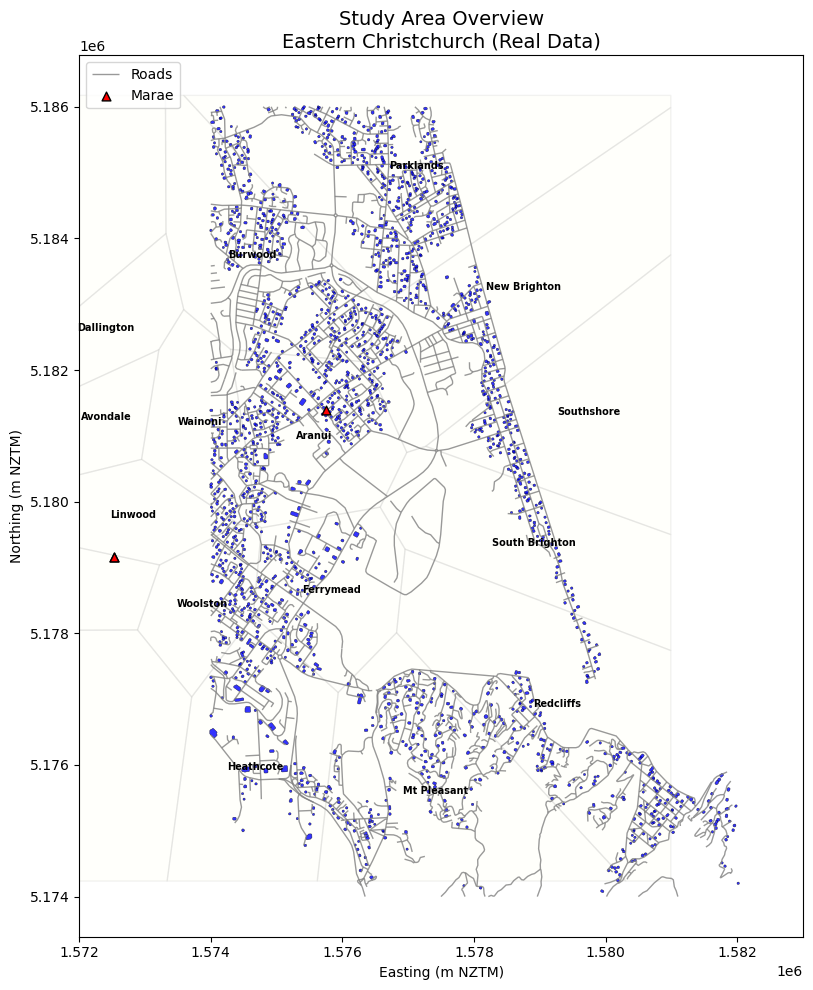

In [13]:
# Overview map of all layers
fig, ax = plt.subplots(figsize=(12, 10))

suburbs.plot(ax=ax, color='lightyellow', edgecolor='gray', alpha=0.1)
roads.plot(ax=ax, color='gray', linewidth=1.0, alpha=0.8, label='Roads')
buildings.buffer(15).plot(ax=ax, color='blue', edgecolor='black', linewidth=0.3, alpha=0.8, label='Buildings')
marae.plot(ax=ax, color='red', markersize=40, marker='^', 
           edgecolor='black', zorder=5, label='Marae')

# Label suburbs
for _, row in suburbs.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                fontsize=7, ha='center', va='center', fontweight='bold')

ax.set_xlim(1.572e6, 1.583e6)
ax.set_title("Study Area Overview\nEastern Christchurch (Real Data)", fontsize=14)
ax.set_xlabel("Easting (m NZTM)")
ax.set_ylabel("Northing (m NZTM)")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 2. Attribute Queries: Filtering by Column Values

Attribute queries let you **select features based on their properties**
(not their location). This is like SQL WHERE clauses but using pandas syntax.

### Common Query Patterns
```python
# Exact match
gdf[gdf['column'] == 'value']

# Comparison
gdf[gdf['column'] > threshold]

# Multiple conditions (AND)
gdf[(gdf['col1'] == 'A') & (gdf['col2'] > 5)]

# Multiple conditions (OR)
gdf[(gdf['col1'] == 'A') | (gdf['col1'] == 'B')]

# Value in a list
gdf[gdf['column'].isin(['A', 'B', 'C'])]
```

In [14]:
# Filter buildings by type
residential = buildings[buildings['type'] == 'Residential']
print(f"Residential buildings: {len(residential)} of {len(buildings)} total")

# Filter buildings in the low-elevation zone (at risk from sea-level rise)
low_elevation = buildings[buildings['elevation_m'] <= 5.0]
print(f"Buildings at 0-5m elevation: {len(low_elevation)}")

# Combined filter: residential buildings at low elevation
at_risk = buildings[(buildings['type'] == 'Residential') & (buildings['elevation_m'] <= 5.0)]
print(f"Residential buildings at risk: {len(at_risk)}")

Residential buildings: 1398 of 2056 total
Buildings at 0-5m elevation: 880
Residential buildings at risk: 594


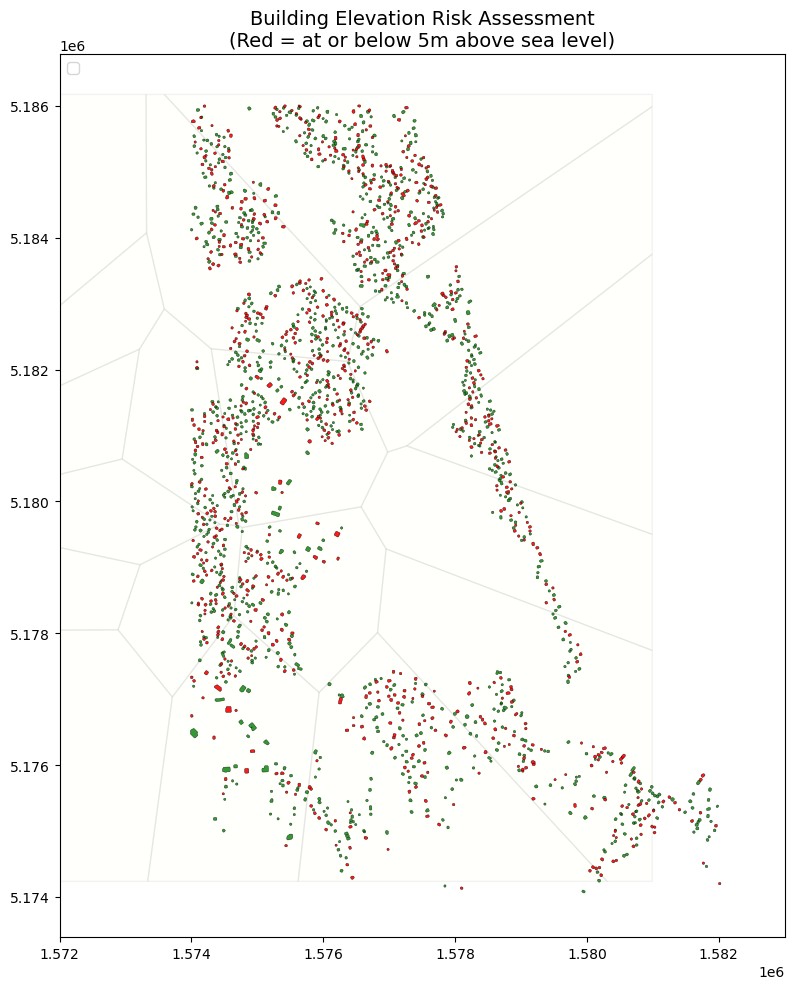

In [17]:
# Visualise at-risk vs safe buildings
fig, ax = plt.subplots(figsize=(12, 10))
suburbs.plot(ax=ax, color='lightyellow', edgecolor='gray', alpha=0.1)

safe = buildings[buildings['elevation_m'] > 5.0]
safe.buffer(15).plot(ax=ax, color='green', edgecolor='black', linewidth=0.3, alpha=0.8, label=f'Above 5m ({len(safe)})')
low_elevation.buffer(15).plot(ax=ax, color='red', edgecolor='black', linewidth=0.3, alpha=0.9,
                   label=f'At or below 5m ({len(low_elevation)})')

ax.set_xlim(1.572e6, 1.583e6)
ax.set_title("Building Elevation Risk Assessment\n(Red = at or below 5m above sea level)", fontsize=14)
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

### Your Turn: Attribute Queries

Filter and count the number of:
1. Arterial roads with a speed limit of 60 km/h or higher
2. Buildings with floor area > 300 m2
3. Suburbs with a deprivation index of 7 or higher (most deprived)

In [ ]:
# 🔧 YOUR TURN — three attribute queries. Fill in the ... blanks.
# All the patterns come from the attribute-query examples above.

# TODO 1: Arterial/Highway roads with a speed limit of 60 km/h or more.
#   Combine two conditions with & — each condition wrapped in ( ).
#   For "value is one of several", use: roads['road_type'].isin(['Arterial', 'Highway'])
fast_roads = ...
print(f"Arterial/Highway roads (>=60 km/h): {len(fast_roads)}")

# TODO 2: Buildings with floor area over 300 m² (column: 'floor_area_m2').
large_buildings = ...
print(f"Large buildings (>300 m2): {len(large_buildings)}")

# TODO 3: Suburbs with a deprivation index of 7 or higher (column: 'deprivation_idx').
deprived = ...
print(f"Most deprived suburbs (idx >= 7): {len(deprived)}")

# Show which suburbs they are:
print(deprived[['name', 'deprivation_idx', 'population']].to_string(index=False))


## 3. Table Joins (Non-Spatial)

Table joins combine two datasets by a **shared key column** -- just like SQL JOINs
or VLOOKUP in Excel. This is how you attach additional attribute data to your
spatial features.

### When to Use Table Joins vs Spatial Joins
| Join Type | Key | Use When |
|-----------|-----|----------|
| **Table join** (`.merge()`) | Shared attribute column | Linking valuation data to building IDs |
| **Spatial join** (`gpd.sjoin()`) | Shared geography | Finding which suburb each building is in |

In [19]:
# Create an external table with building valuation data
# (In practice, this might come from a council rates database)
np.random.seed(42)
valuation_data = pd.DataFrame({
    'bldg_id': buildings['bldg_id'].values,
    'capital_value_nzd': np.random.randint(200000, 2000000, len(buildings)),
    'land_value_nzd': np.random.randint(100000, 800000, len(buildings)),
    'last_assessed': np.random.choice(['2022', '2023', '2024'], len(buildings))
})

print("Valuation table (first 5 rows):")
print(valuation_data.head())
print(f"\nType: {type(valuation_data)}  (plain DataFrame, no geometry)")

Valuation table (first 5 rows):
    bldg_id  capital_value_nzd  land_value_nzd last_assessed
0  BLD-0000             321958          426032          2024
1  BLD-0001             871155          697897          2024
2  BLD-0002             331932          353973          2023
3  BLD-0003            1614414          383097          2023
4  BLD-0004             459178          476826          2022

Type: <class 'pandas.core.frame.DataFrame'>  (plain DataFrame, no geometry)


In [20]:
# Merge valuation data into the spatial buildings dataset
buildings_valued = buildings.merge(valuation_data, on='bldg_id', how='left')

print(f"Before merge: {buildings.shape[1]} columns")
print(f"After merge:  {buildings_valued.shape[1]} columns")
print(f"Still a GeoDataFrame: {type(buildings_valued)}")
print(f"\nNew columns added: {[c for c in buildings_valued.columns if c not in buildings.columns]}")

Before merge: 5 columns
After merge:  8 columns
Still a GeoDataFrame: <class 'geopandas.geodataframe.GeoDataFrame'>

New columns added: ['capital_value_nzd', 'land_value_nzd', 'last_assessed']


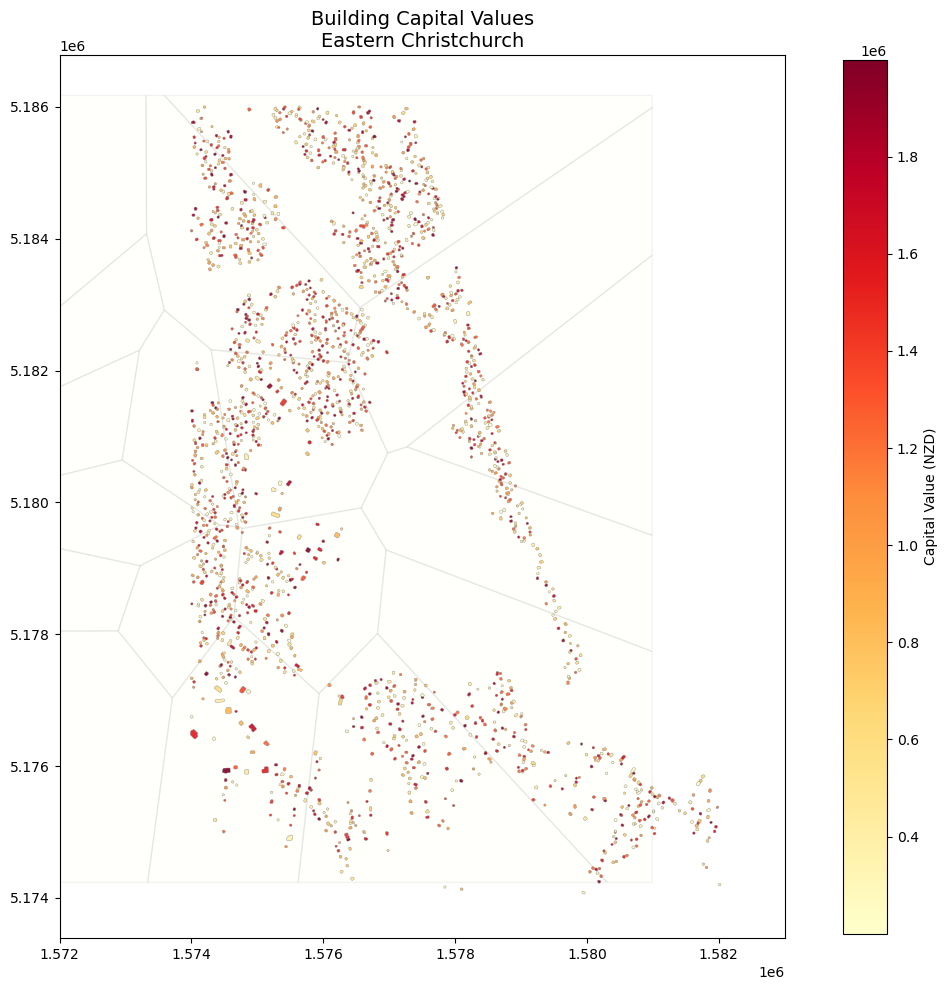

In [24]:
# Map building footprints coloured by capital value
fig, ax = plt.subplots(figsize=(12, 10))
suburbs.plot(ax=ax, color='lightyellow', edgecolor='gray', alpha=0.1)
bv_display = buildings_valued.copy()
bv_display['geometry'] = bv_display.geometry.buffer(15)
bv_display.plot(
    ax=ax, column='capital_value_nzd', cmap='YlOrRd',
    legend=True, edgecolor='gray', linewidth=0.3, alpha=0.9,
    legend_kwds={'label': 'Capital Value (NZD)', 'shrink': .6}
)
ax.set_xlim(1.572e6, 1.583e6)
ax.set_title("Building Capital Values\nEastern Christchurch", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Spatial Joins

A **spatial join** assigns attributes from one layer to another based on their
**geographic relationship** (e.g., which suburb is each building in?).

### `gpd.sjoin()` Parameters
| Parameter | Description |
|-----------|-------------|
| `left_df` | The GeoDataFrame you want to add attributes TO |
| `right_df` | The GeoDataFrame you want to get attributes FROM |
| `how` | Join type: `'inner'`, `'left'`, `'right'` |
| `predicate` | Spatial relationship: `'intersects'`, `'within'`, `'contains'` |

### The Key Question
> "Which suburb is each building located in?"

In [26]:
# We need to use building centroids (points) for a 'within' join against suburb polygons
buildings_pts = buildings_valued.copy()
buildings_pts['geometry'] = buildings_pts.geometry.centroid

# Spatial join: assign each building to its suburb
buildings_with_suburb = gpd.sjoin(
    buildings_pts,            # left: buildings (centroids)
    suburbs,                  # right: suburbs (polygons)
    how='inner',              # keep only matches
    predicate='within'        # building centroid must be WITHIN the polygon
)

print(f"Buildings matched to suburbs: {len(buildings_with_suburb)} of {len(buildings_valued)}")
print(f"\nNew columns from spatial join:")
print([c for c in buildings_with_suburb.columns if c not in buildings_valued.columns])
print(f"\nSample result:")
print(buildings_with_suburb[['bldg_id', 'type', 'name', 'deprivation_idx']].head(10))

Buildings matched to suburbs: 2007 of 2056

New columns from spatial join:
['index_right', 'name', 'population', 'deprivation_idx', 'area_km2']

Sample result:
     bldg_id         type         name  deprivation_idx
2   BLD-0002   Commercial  Mt Pleasant                2
5   BLD-0005  Residential  Mt Pleasant                2
7   BLD-0007   Industrial  Mt Pleasant                2
8   BLD-0008  Residential  Mt Pleasant                2
9   BLD-0009   Commercial  Mt Pleasant                2
10  BLD-0010  Residential  Mt Pleasant                2
11  BLD-0011       School    Redcliffs                3
12  BLD-0012   Industrial    Redcliffs                3
13  BLD-0013  Residential    Heathcote                4
14  BLD-0014  Residential    Heathcote                4


In [27]:
# Summarise: count buildings per suburb
summary = buildings_with_suburb.groupby('name').agg(
    building_count=('bldg_id', 'count'),
    avg_elevation=('elevation_m', 'mean'),
    total_value=('capital_value_nzd', 'sum'),
    deprivation=('deprivation_idx', 'first')
).reset_index().sort_values('building_count', ascending=False)

print("Buildings per Suburb:")
print(summary.to_string(index=False))

Buildings per Suburb:
          name  building_count  avg_elevation  total_value  deprivation
     Parklands             400       5.859000    428760047            4
       Burwood             286       5.755944    337434279            5
        Aranui             267       6.187640    295627450            9
     Redcliffs             190       5.818947    205812733            3
   Mt Pleasant             179       5.984916    195104932            2
  New Brighton             142       6.429577    153461522            7
     Ferrymead             103       6.063107    112746862            5
     Heathcote             103       6.151456    108395318            4
      Woolston             100       5.781000    112313715            7
       Wainoni              89       5.517978     94384514            8
    Southshore              82       6.074390     85887456            5
South Brighton              52       5.825000     48081150            6
       Linwood              14       6.721

### Your Turn: Spatial Join Practice

Perform a spatial join to find which suburb each **road** passes through.
How many roads are in each suburb? Which suburb has the most road infrastructure?

In [ ]:
# 🔧 YOUR TURN — which suburb has the most road infrastructure?

# TODO 1: Spatial join roads → suburbs, just like the buildings join above,
#   BUT roads are LineStrings: use predicate='intersects' instead of 'within'.
#   Command: gpd.sjoin(left_gdf, right_gdf, how=..., predicate=...)
roads_with_suburb = ...

# ⚠ NEW detail: BOTH layers have a 'name' column. When a join would create
#   duplicate column names, the right-hand one is renamed — so after this
#   join the SUBURB name is in the column 'name_right'.
print(roads_with_suburb.columns.tolist())   # confirm you can see 'name_right'

# TODO 2: Count roads and total road length per suburb.
#   Same groupby + named-agg pattern as the buildings-per-suburb summary above:
#     .groupby('name_right').agg(
#         road_count=('road_id', 'count'),
#         total_length_km=('length_m', 'sum'),   # then divide by 1000 for km
#     )
#   Finish with .reset_index() and .sort_values(..., ascending=False)
#   so the suburb with the most roads is on top.
road_summary = ...

print("Road infrastructure per Suburb:")
print(road_summary.to_string(index=False))


## 5. Buffer Analysis

A **buffer** creates a zone of a specified distance around a feature.
In engineering, buffers are used for:
- **Setback zones** around roads (noise, safety)
- **Impact zones** around pollution sources
- **Service areas** around facilities like marae or schools

### Important: Buffer distance units = CRS units!
If your CRS is in metres (NZTM2000), buffer distance is in metres.  
If your CRS is in degrees (WGS84), buffer distance is in degrees -- NOT useful!

Original geometry type: MultiLineString
Buffered geometry type: Polygon


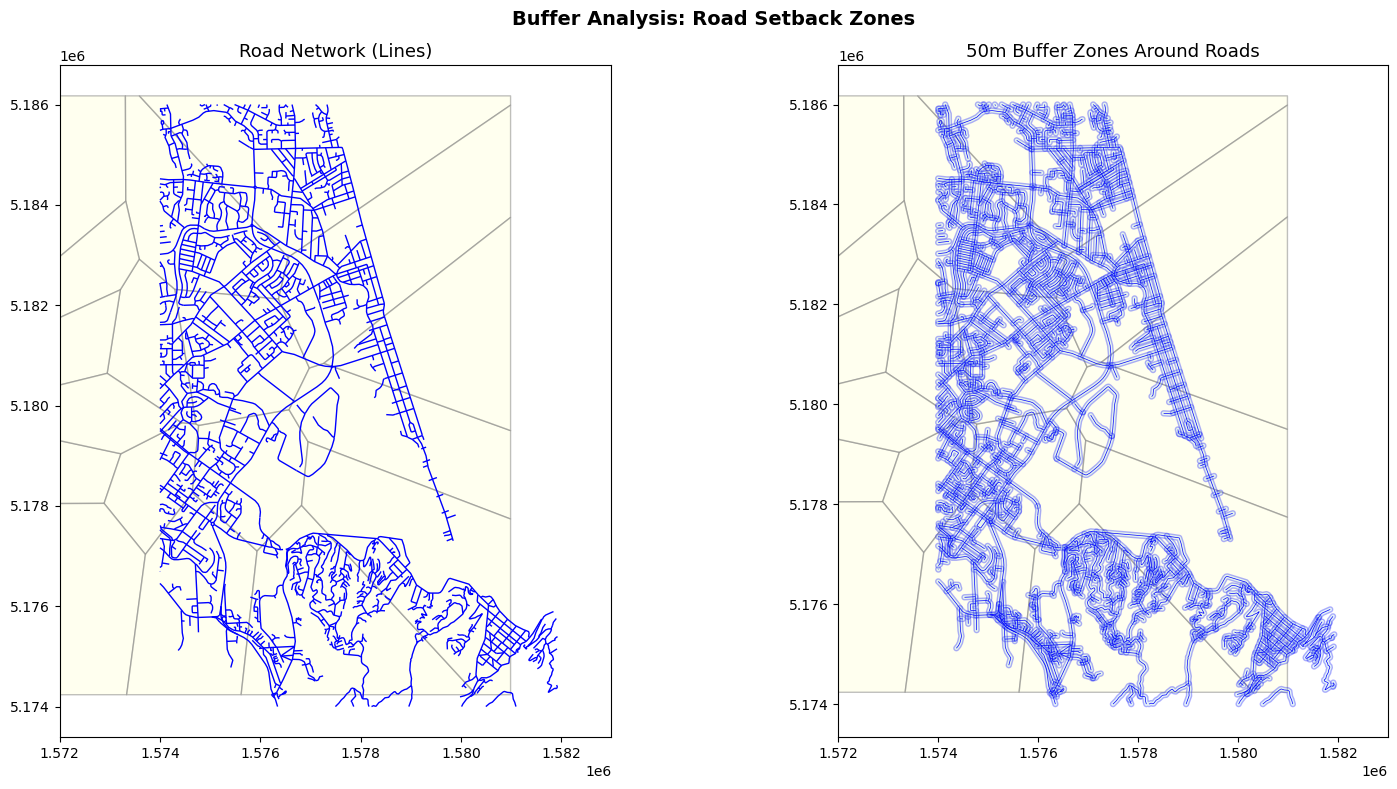

In [29]:
# Buffer: Create 50m setback zone around each road
road_buffers = roads.copy()
road_buffers['geometry'] = roads.geometry.buffer(50)  # 50 metres

print(f"Original geometry type: {roads.geom_type.iloc[0]}")
print(f"Buffered geometry type: {road_buffers.geom_type.iloc[0]}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Before buffer
suburbs.plot(ax=axes[0], color='lightyellow', edgecolor='gray', alpha=0.5)
roads.plot(ax=axes[0], color='blue', linewidth=1)
axes[0].set_title("Road Network (Lines)", fontsize=13)
axes[0].set_xlim(1.572e6, 1.583e6)

# After buffer
suburbs.plot(ax=axes[1], color='lightyellow', edgecolor='gray', alpha=0.5)
road_buffers.plot(ax=axes[1], color='lightblue', edgecolor='blue', alpha=0.3)
roads.plot(ax=axes[1], color='blue', linewidth=0.5)
axes[1].set_title("50m Buffer Zones Around Roads", fontsize=13)
axes[1].set_xlim(1.572e6, 1.583e6)
plt.suptitle("Buffer Analysis: Road Setback Zones", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Buildings within 50m of a road: 1724 of 2056


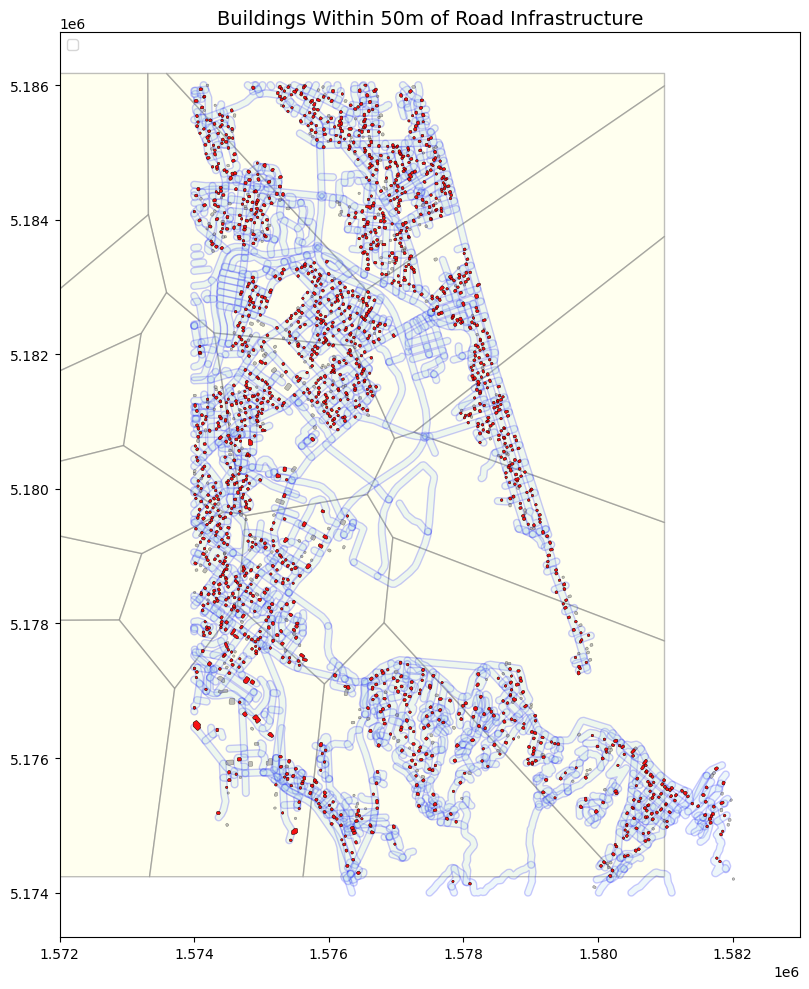

In [31]:
# Find buildings within the road buffer zones
buildings_near_roads = gpd.sjoin(
    buildings_pts, road_buffers, how='inner', predicate='within'
)
# Remove duplicates (a building may be near multiple roads)
buildings_near_roads = buildings_near_roads.drop_duplicates(subset='bldg_id')

print(f"Buildings within 50m of a road: {len(buildings_near_roads)} of {len(buildings)}")

# Visualise
fig, ax = plt.subplots(figsize=(12, 10))
suburbs.plot(ax=ax, color='lightyellow', edgecolor='gray', alpha=0.5)
road_buffers.plot(ax=ax, color='lightblue', edgecolor='blue', alpha=0.2)
buildings.buffer(15).plot(ax=ax, color='gray', edgecolor='black', linewidth=0.3, alpha=0.5, label='Other buildings')

# Rejoin to original building geometries for display
near_ids = buildings_near_roads['bldg_id'].values
buildings[buildings['bldg_id'].isin(near_ids)].buffer(15).plot(
    ax=ax, color='red', edgecolor='black', linewidth=0.3, alpha=0.9,
    label=f'Within 50m of road ({len(buildings_near_roads)})'
)
ax.set_xlim(1.572e6, 1.583e6)
ax.set_title("Buildings Within 50m of Road Infrastructure", fontsize=14)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 6. Clipping: Extracting Features Within a Boundary

**Clipping** cuts features to the extent of a boundary polygon --
like a cookie cutter. Use `gpd.clip()`.

This is useful when you have city-wide data but only need features
within a specific suburb or study area.

Focus area: Aranui
  Population: 3800
  Deprivation index: 9
  Area: 5.4 km2

Total buildings: 2056 -> Clipped: 270
Total roads: 1063 -> Clipped: 112


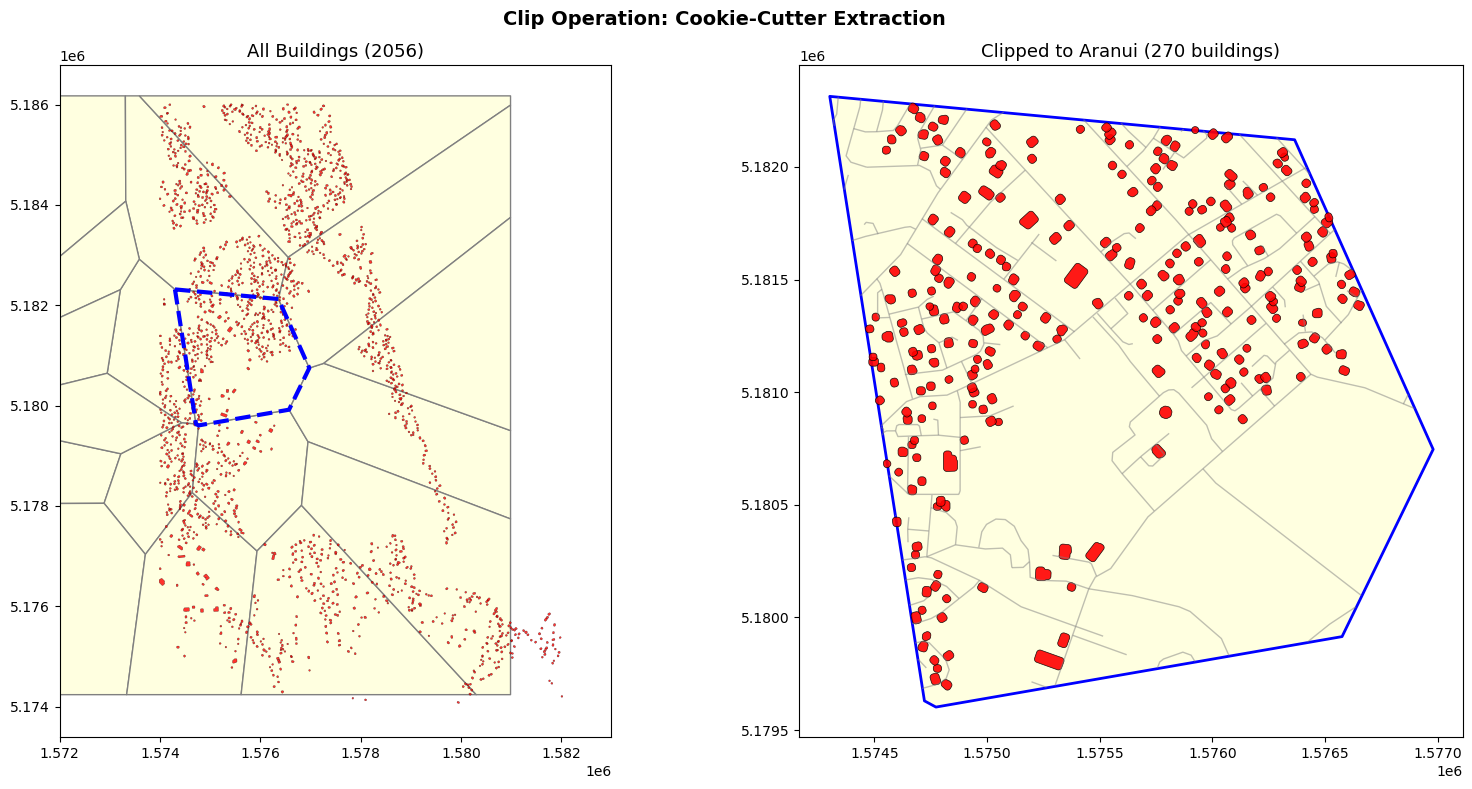

In [36]:
# Select a single suburb as our focus area
focus_suburb = suburbs[suburbs['name'] == 'Aranui']
print(f"Focus area: Aranui")
print(f"  Population: {focus_suburb['population'].values[0]}")
print(f"  Deprivation index: {focus_suburb['deprivation_idx'].values[0]}")
print(f"  Area: {focus_suburb['area_km2'].values[0]:.1f} km2")

# Clip buildings and roads to the focus suburb
clipped_buildings = gpd.clip(buildings, focus_suburb)
clipped_roads = gpd.clip(roads, focus_suburb)
print(f"\nTotal buildings: {len(buildings)} -> Clipped: {len(clipped_buildings)}")
print(f"Total roads: {len(roads)} -> Clipped: {len(clipped_roads)}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Full extent
suburbs.plot(ax=axes[0], color='lightyellow', edgecolor='gray')
buildings.buffer(15).plot(ax=axes[0], color='red', edgecolor='black', linewidth=0.2, alpha=0.8)
focus_suburb.plot(ax=axes[0], facecolor='none', edgecolor='blue', linewidth=3, linestyle='--')
axes[0].set_title(f"All Buildings ({len(buildings)})", fontsize=13)
axes[0].set_xlim(1.572e6, 1.583e6)


# Clipped
focus_suburb.plot(ax=axes[1], color='lightyellow', edgecolor='blue', linewidth=2)
clipped_roads.plot(ax=axes[1], color='gray', linewidth=1, alpha=0.5)
clipped_buildings.buffer(15).plot(ax=axes[1], color='red', edgecolor='black', linewidth=0.5, alpha=0.9)
axes[1].set_title(f"Clipped to Aranui ({len(clipped_buildings)} buildings)", fontsize=13)

plt.suptitle("Clip Operation: Cookie-Cutter Extraction", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Spatial Aggregation: Dissolve

**Dissolve** merges geometries based on a shared attribute -- the spatial equivalent of
`GROUP BY` in SQL. It combines both the geometry (union) and the attributes (aggregate).

### Example
Merge individual suburbs by deprivation category (High / Medium / Low).

Dissolved summary:
dep_category  population  deprivation_idx   area_km2
   Low (1-3)        8300         2.666667  63.093548
Medium (4-6)       25300         5.000000 123.336611
 High (7-10)       23100         7.714286  30.803424


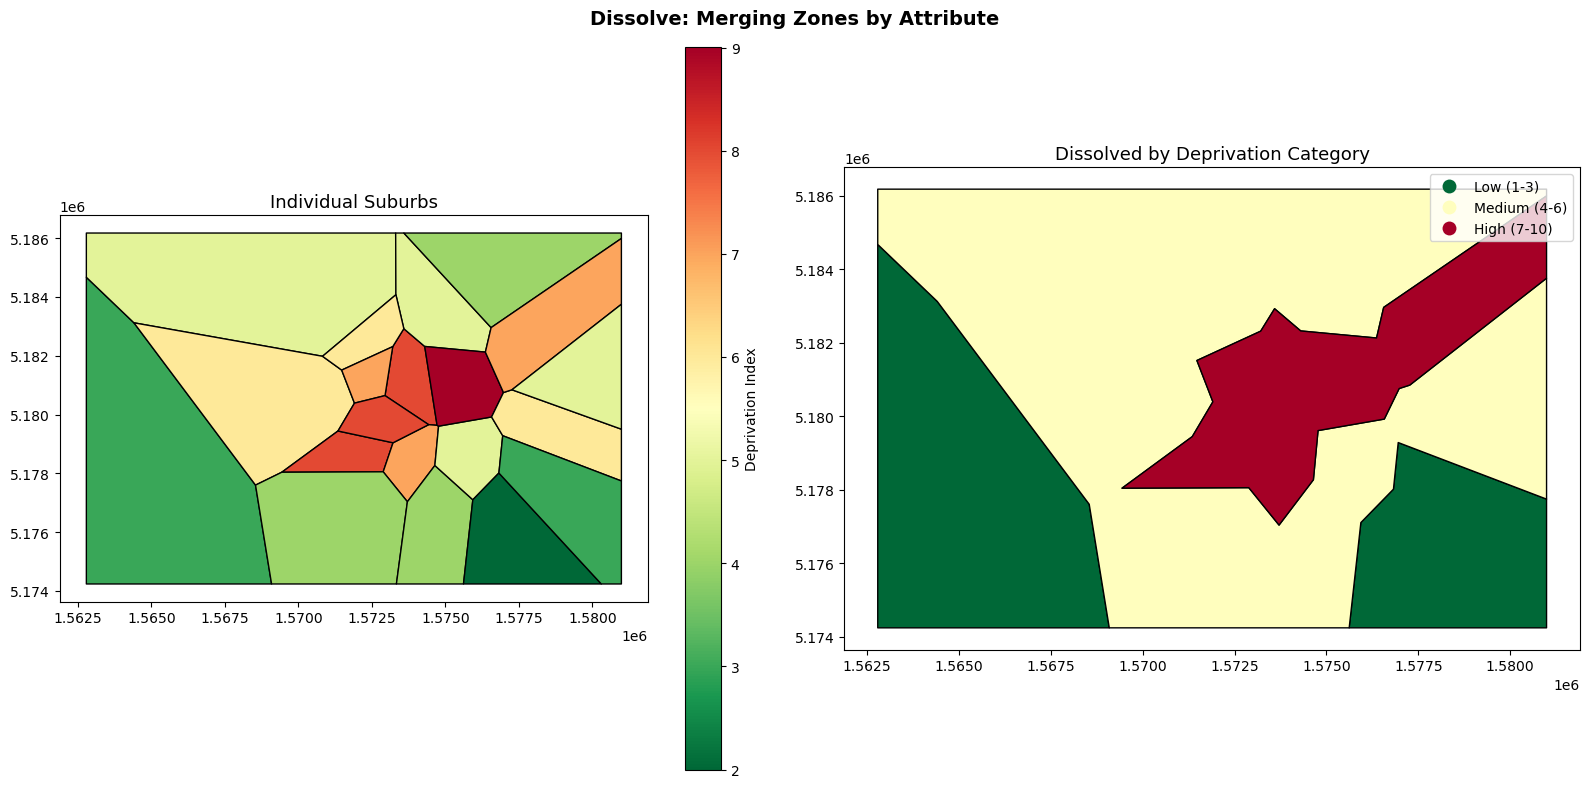

In [42]:
# Classify deprivation into categories
suburbs['dep_category'] = pd.cut(
    suburbs['deprivation_idx'],
    bins=[0, 3, 6, 10],
    labels=['Low (1-3)', 'Medium (4-6)', 'High (7-10)']
)

# Dissolve: merge suburbs by deprivation category
dissolved = suburbs.dissolve(by='dep_category', aggfunc={
    'population': 'sum',
    'deprivation_idx': 'mean',
    'area_km2': 'sum'
}).reset_index()

print("Dissolved summary:")
print(dissolved[['dep_category', 'population', 'deprivation_idx', 'area_km2']].to_string(index=False))

# Map
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

suburbs.plot(ax=axes[0], column='deprivation_idx', cmap='RdYlGn_r', 
             legend=True, edgecolor='black',
             legend_kwds={'label': 'Deprivation Index'})
axes[0].set_title("Individual Suburbs", fontsize=13)


dissolved.plot(ax=axes[1], column='dep_category', cmap='RdYlGn_r', 
               legend=True, edgecolor='black')
axes[1].set_title("Dissolved by Deprivation Category", fontsize=13)

plt.suptitle("Dissolve: Merging Zones by Attribute", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Interactive Web Maps with `.explore()`

GeoPandas integrates with **Folium** to create interactive maps that you can
zoom, pan, and click on. This uses `.explore()` instead of `.plot()`.

### When to Use Each
| Method | Best For |
|--------|----------|
| `.plot()` | Static maps for reports, publications |
| `.explore()` | Interactive exploration, presentations, web |

In [45]:
# Interactive map of buildings coloured by type

try:
    m = buildings.to_crs(epsg=4326).explore(
        column='type',
        cmap='Set1',
        tooltip=['bldg_id', 'type', 'elevation_m', 'floor_area_m2'],
        popup=True,
        legend=True,
        style_kwds={'fillOpacity': 0.6, 'weight': 1},
        tiles='CartoDB positron',
        name='Buildings'
    )

    # Add suburb boundaries as overlay
    suburbs.to_crs(epsg=4326).explore(
        m=m,
        color='lightblue',
        style_kwds={'fillOpacity': 0.1, 'weight': 2},
        tooltip=['name', 'population', 'deprivation_idx'],
        name='Suburbs'
    )

    # Add marae
    marae.to_crs(epsg=4326).explore(
        m=m,
        color='blue',
        tooltip=marae.columns.drop('geometry').tolist(),
        marker_kwds={'radius': 8},
        name='Marae'
    )

    import folium
    folium.LayerControl().add_to(m)
    display(m)
except ImportError:
    print("Install folium for interactive maps: pip install folium")
    print("Then restart the kernel and re-run this cell.")

## 9. Exposure Assessment: Putting It All Together

Now combine all the techniques to answer the key engineering question:

> **How many people and buildings are exposed to coastal flooding
> in the 0-5 m elevation zone, broken down by suburb deprivation level?**

In [46]:
# Step 1: Identify at-risk buildings (elevation <= 5m)
at_risk_buildings = buildings_valued[buildings_valued['elevation_m'] <= 5.0].copy()
print(f"Step 1: {len(at_risk_buildings)} buildings in 0-5m zone")

# Step 2: Spatial join to get suburb attributes (use centroids for polygon-in-polygon)
at_risk_pts = at_risk_buildings.copy()
at_risk_pts['geometry'] = at_risk_pts.geometry.centroid
at_risk_with_suburb = gpd.sjoin(at_risk_pts, suburbs, how='inner', predicate='within')
print(f"Step 2: {len(at_risk_with_suburb)} matched to suburbs")

# Step 3: Summarise by deprivation category
at_risk_with_suburb['dep_category'] = pd.cut(
    at_risk_with_suburb['deprivation_idx'],
    bins=[0, 3, 6, 10],
    labels=['Low', 'Medium', 'High']
)

exposure_summary = at_risk_with_suburb.groupby('dep_category').agg(
    num_buildings=('bldg_id', 'count'),
    total_value_nzd=('capital_value_nzd', 'sum'),
    avg_elevation=('elevation_m', 'mean')
).reset_index()

print(f"\nStep 3: Exposure Summary by Deprivation Level")
print("=" * 60)
print(exposure_summary.to_string(index=False))
print(f"\nTotal buildings at risk: {exposure_summary['num_buildings'].sum()}")
print(f"Total value at risk: ${exposure_summary['total_value_nzd'].sum():,.0f}")

Step 1: 880 buildings in 0-5m zone
Step 2: 864 matched to suburbs

Step 3: Exposure Summary by Deprivation Level
dep_category  num_buildings  total_value_nzd  avg_elevation
         Low            159        177622700       2.480503
      Medium            461        501186595       2.548807
        High            244        274876689       2.581967

Total buildings at risk: 864
Total value at risk: $953,685,984


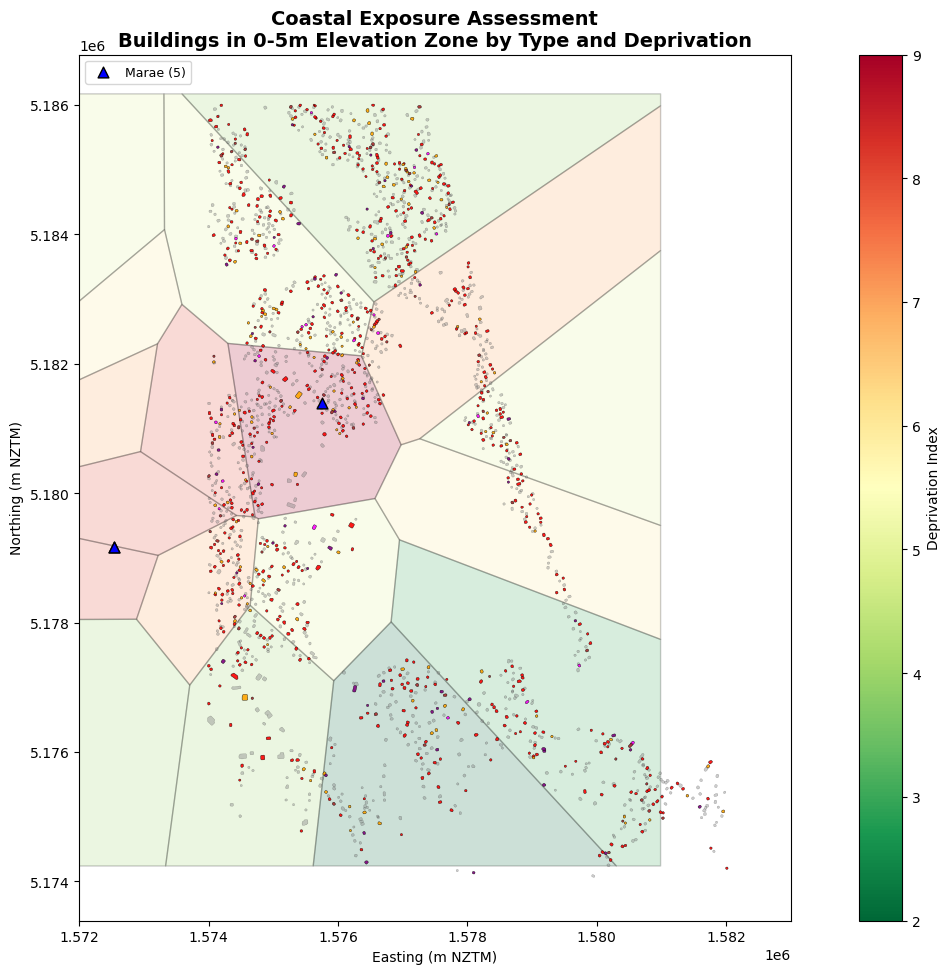

In [51]:
# Final visualisation: exposure assessment map
fig, ax = plt.subplots(figsize=(14, 10))

# Base map: suburbs by deprivation
suburbs.plot(ax=ax, column='deprivation_idx', cmap='RdYlGn_r',
             legend=True, alpha=0.2, edgecolor='black',
             legend_kwds={'label': 'Deprivation Index'})

# Safe buildings (gray)
safe = buildings_valued[buildings_valued['elevation_m'] > 5.0]
safe.buffer(15).plot(ax=ax, color='gray', edgecolor='black', linewidth=0.2, alpha=0.4, label=f'Above 5m ({len(safe)})')

# At-risk buildings by type
for btype, color in [('Residential', 'red'), ('Commercial', 'orange'),
                      ('School', 'purple'), ('Hospital', 'magenta'),
                      ('Industrial', 'brown')]:
    subset = at_risk_buildings[at_risk_buildings['type'] == btype]
    if len(subset) > 0:
        subset.buffer(15).plot(ax=ax, color=color, alpha=0.9,
                   edgecolor='black', linewidth=0.3,
                   label=f'{btype} at risk ({len(subset)})')

# Add marae locations
marae.plot(ax=ax, color='blue', markersize=60, marker='^',
           edgecolor='black', linewidth=1, zorder=5, label=f'Marae ({len(marae)})')

ax.set_xlim(1.572e6, 1.583e6)
ax.set_title("Coastal Exposure Assessment\nBuildings in 0-5m Elevation Zone by Type and Deprivation",
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlabel("Easting (m NZTM)")
ax.set_ylabel("Northing (m NZTM)")
plt.tight_layout()
plt.show()

## 10. Summary and Reflection

### What You Learned Today
1. **GeoPackage loading**: Multi-layer spatial databases with `pyogrio.list_layers()` and `gpd.read_file()`
2. **Attribute queries**: Filter data by column values using pandas syntax
3. **Table joins**: `.merge()` links attribute tables by shared key columns
4. **Spatial joins**: `gpd.sjoin()` assigns attributes based on geographic relationships
5. **Buffer analysis**: Create proximity zones around features
6. **Clipping**: Extract features within a study area boundary
7. **Dissolve**: Merge geometries by attribute with aggregation
8. **Interactive maps**: `.explore()` creates zoomable web maps

### Engineering Takeaways
- **Spatial joins are the workhorse** of GIS analysis -- linking features to zones
- **Buffer distances depend on CRS units** -- always use projected coordinates (NZTM)
- **Dissolve + groupby** enables spatial summary statistics for reporting
- **The exposure framework** (Hazard zone + Assets + Vulnerability indicators) is fundamental
- **Real data is messy** -- buildings don't align perfectly with boundaries, some fall outside

### Reflection Questions
1. Why is a spatial join necessary instead of a table join when determining which buildings are in a flood zone?
2. How would changing the buffer distance from 50m to 100m affect your road impact assessment?
3. What additional data would you need to convert an exposure assessment into a full risk assessment?
4. Why did we use building centroids for the spatial join to suburbs, rather than the full footprint polygons?

---

### Assessment: Lab Sign-Off

**This lab is not complete until you have submitted your sign-off to LEARN.**

**Step 1 — Self-check.** Make sure you can do each of these:

- [ ] Loaded a multi-layer GeoPackage and described its contents
- [ ] Performed attribute queries to filter features
- [ ] Completed a spatial join and explained how it works
- [ ] Created buffer zones and identified features within them
- [ ] Produced the exposure summary table broken down by deprivation
- [ ] Created at least one interactive map using `.explore()`

**Step 2 — Take the sign-off quiz.**

1. Download **`Lab2_SignOff.html`** from LEARN and open it in your web browser.
2. Enter your full name and University ID, then answer the 10 questions.
3. You need **8/10** to pass. You can retake it as often as you like — each
   attempt draws a new set of questions, and every answer comes with an explanation.
4. When you pass, click **Download Sign-Off PNG**. This saves a file called
   `ENCN205_Lab2_<yourID>.png` to your computer.

**Step 3 — Submit.** Upload `ENCN205_Lab2_<yourID>.png` to the **Lab 2 Sign-Off**
submission on LEARN.

> Your PNG records your name, ID, score, and a timestamp, encoded in the QR code.
> It is your proof of completion — show it to your tutor if they ask.
